# Image compression using Singular Value Decomposition (SVD)

SVD is a mathematical technique for factorizing a matrix into three separate matrices and has a wide range of applications in various fields, including data compression.

Applying Singular Value Decomposition (SVD) to an image can help us understand Latent Semantic Analysis (LSA) by illustrating how SVD reduces high-dimensional data to a lower-dimensional representation while preserving essential structure, a core principle of LSA.

Library imports

In [1]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np

Loads an image

In [2]:
A = imread('data/dog.jpg')

An RGB image can be represented as a 3D NumPy array with shape (height, width, channels), where channels is usually 3 (for Red, Green, Blue)

In [3]:
A.shape

(612, 541, 3)

A grayscale image is typically represented as a 2D NumPy array with shape (height, width), where each element corresponds to the intensity of a pixel (e.g., a value between 0 and 255 for an 8-bit image). We can convert an image to grayscale by computing the mean across the last axis of the array A, which typically corresponds to the color channels. 

In [4]:
X = np.mean(A, -1)
X.shape

(612, 541)

The rank of a matrix is the maximum number of linearly independent rows (or equivalently, columns) in the matrix. It indicates the dimensionality of the vector space spanned by the rows or columns.

In [5]:
np.linalg.matrix_rank(X)

np.int64(335)

Let's define a function to plot the image

In [6]:
def show_image(matrix, rank=False):
  img = plt.imshow(matrix)
  img.set_cmap('gray')    # set the colormap of an image to grayscale
  plt.axis('off')
  if rank:
    plt.title(f"Rank {rank}")
  plt.show()

Now we plot the matrix using the previous defined function

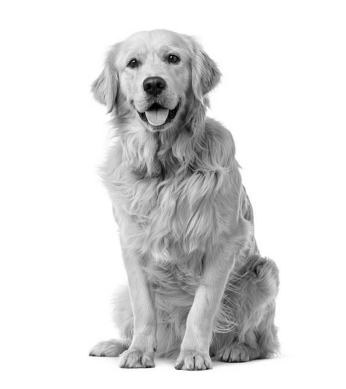

In [7]:
show_image(X)

The Singular Value Decomposition (SVD) of a matrix is given by: 

$$ A = U \Sigma V^T $$

where:
- $ A $ is an ($m \times n$) matrix.
- $ U $ is an ($m \times m$) orthogonal matrix (left singular vectors).
- $ \Sigma $ is an ($m \times n$) diagonal matrix with non-negative singular values ( $ \sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r \geq 0 $).
- $ V^T $ is the transpose of an ( $n \times n$) orthogonal matrix $V$ (right singular vectors).
- The rank $𝑟$ is the number of non-zero singular values in $\Sigma$.

In [8]:
u, s, vt = np.linalg.svd(X)
s = np.diag(s)

u.shape, s.shape, vt.shape

((612, 612), (541, 541), (541, 541))

We can reconstruct the original matrix using a low-rank approximation with fewer than $r$ components (i.e., using only the top 
$𝑘 < 𝑟$ singular values and vectors). This is lossy but can capture most of the matrix's information.

To approximate $A$ with a lower rank $𝑘 < 𝑟$, we use only the top $k$ singular values and their corresponding singular vectors. The low-rank approximation $A_k$ is:

$A_k = U_k \Sigma_k V_k^T$

where:

- $U_k$ is the $m \times k$ matrix containing the first $k$ columns of $U$.
- $\Sigma$ is the $k \times k$ diagonal matrix containing the top $k$ singular values $ \sigma_1, \sigma_2, ... \sigma_k$.
- $V_k^T$ is the $k \times n$ matrix containing the first $k$ rows of $V_k^T$.

This approximation is achieved by matrix multiplication.

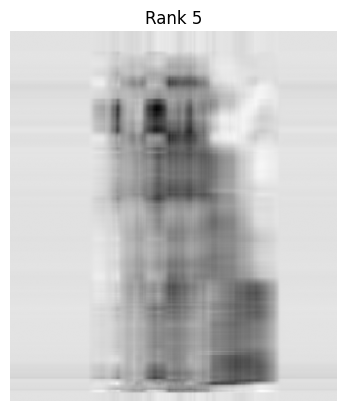

In [9]:
rank = 5

approx = u[:,:rank] @ s[0:rank,:rank] @ vt[:rank,:]
show_image(approx, rank)